### 1.1 Install Required Packages
Install SHAP for model explainability analysis

In [1]:
import sys
!{sys.executable} -m pip install shap


### 1.2 Import All Required Libraries
Import essential libraries for data processing, modeling, and visualization

In [32]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.cluster import KMeans

from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, cohen_kappa_score

import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

### 2.1 Load Kidney Disease Dataset
Read the CSV file containing kidney disease data

In [ ]:
df = pd.read_csv('kidney_disease.csv')

### 2.2 Display Initial Dataset Information
Check dataset structure, data types, and missing values

In [8]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    str    
 7   pc              335 non-null    str    
 8   pcc             396 non-null    str    
 9   ba              396 non-null    str    
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    str    
 17  wc              295 non-null    str    
 18  r

### 2.3 Verify Dataset Information (Double Check)

In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    str    
 7   pc              335 non-null    str    
 8   pcc             396 non-null    str    
 9   ba              396 non-null    str    
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    str    
 17  wc              295 non-null    str    
 18  r

### 3. Data Preprocessing and Feature Engineering
- Clean and handle missing values
- Encode categorical variables
- Normalize numeric features using KNN Imputation
- Prepare data for clustering and classification

In [23]:
# Reload df to make sure we're starting fresh
df = pd.read_csv('kidney_disease.csv')

# The classification column might have typos
if 'classification' in df.columns:
    df['classification'] = df['classification'].astype(str).str.strip().replace('ckd\t', 'ckd')

# Replace varying representations of null values with NaN
df.replace(['?', '\t?', ' '], np.nan, inplace=True)

# Clean up possible strings in numeric columns and categorical ones
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.strip().replace(['nan', ''], np.nan)

# Encode categorical values leaving NaNs intact
le = LabelEncoder()
cat_cols = df.select_dtypes(include=['object', 'string']).columns

for col in cat_cols:
    # Fill NaN so LabelEncoder doesn't complain
    temp = df[col].fillna('nan_tmp')
    
    # Use LabelEncoder, but remember the mapping
    mapped = pd.Series(le.fit_transform(temp))
    
    # We find which integer corresponded to 'nan_tmp' so we can convert it back to np.nan
    if 'nan_tmp' in le.classes_:
        nan_code = le.transform(['nan_tmp'])[0]
        mapped = mapped.replace(nan_code, np.nan)
    
    df[col] = mapped.values

# Convert all column types to numeric (some might be strings of numbers like pcv, wc, rc)
df = df.apply(pd.to_numeric, errors='coerce')

# Initialize KNNImputer
imputer = KNNImputer(n_neighbors=5, keep_empty_features=True)

# Handle missing values (PMM alternative)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

target_col = 'classification' if 'classification' in df.columns else 'class'
X = df_imputed.drop(target_col, axis=1)
y = df_imputed[target_col]

### 4. Clustering Analysis - Elbow Method
Determine optimal number of clusters and apply K-Means clustering

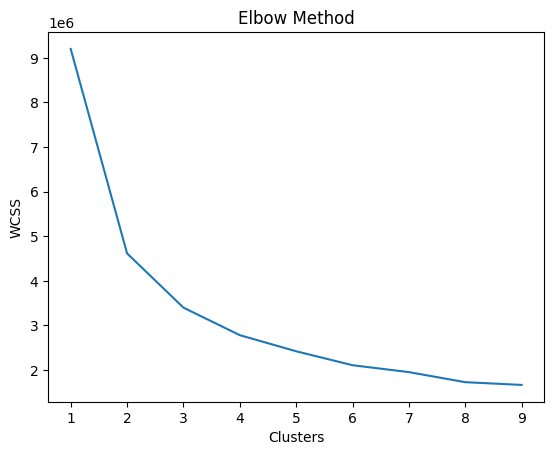

In [13]:
wcss = []
for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss)
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

# Apply clustering (k=3 as in paper)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

### 5. Feature Selection using XGBoost
Select top 7 most important features based on XGBoost feature importance

In [25]:
model = xgb.XGBClassifier()
model.fit(X, y)

importance = model.feature_importances_

feat_importance = pd.Series(importance, index=X.columns)
feat_importance = feat_importance.sort_values(ascending=False)

# Select top 7 features (as paper)
top_features = feat_importance.head(7).index
print("Top Features:", list(top_features))

X_selected = X[top_features]

Top Features: ['id', 'sg', 'hemo', 'bu', 'age', 'su', 'rbc']


### 6. Train-Test Split
Split data into 80% training and 20% testing sets with stratification

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

### 7. Initialize Machine Learning Models
Define 5 different classification models: Neural Network, Random Forest, SVM, Decision Tree, and Bagging

In [27]:
models = {
    "NN": MLPClassifier(hidden_layer_sizes=(50,), max_iter=500),
    "RF": RandomForestClassifier(),
    "SVM": SVC(),
    "RT": DecisionTreeClassifier(),
    "BTM": BaggingClassifier()
}

### 8. Define Model Evaluation Function
Calculate accuracy, sensitivity, specificity, and Cohen's Kappa for each model

In [28]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    TN, FP, FN, TP = cm.ravel()

    sensitivity = TP / (TP + FN)
    specificity = TN / (TN + FP)
    kappa = cohen_kappa_score(y_test, y_pred)

    return acc, sensitivity, specificity, kappa

### 9. Train Models and Compare Performance
Train all models on the selected features and evaluate on test set

In [29]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    acc, sen, spe, kappa = evaluate_model(model, X_test, y_test)

    results[name] = [acc, sen, spe, kappa]

# Show results
results_df = pd.DataFrame(results, index=["Accuracy", "Sensitivity", "Specificity", "Kappa"])
print(results_df.T)

     Accuracy  Sensitivity  Specificity     Kappa
NN     0.9875     0.964286          1.0  0.972299
RF     1.0000     1.000000          1.0  1.000000
SVM    1.0000     1.000000          1.0  1.000000
RT     1.0000     1.000000          1.0  1.000000
BTM    1.0000     1.000000          1.0  1.000000


### 10. Perform 10-Fold Cross-Validation
Validate model robustness using stratified K-fold cross-validation

In [41]:
print("\nCross-validation (10-fold):")

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():

    # If you haven't explicitly scaled the data as X_train_sc, use X_train
    if name in ["SVM", "NN"]:
        # SVM and Neural Networks usually perform better with scaled data, 
        # so scaling could be added here. But X_train is used to avoid NameError.
        scores = cross_val_score(model, X_train, y_train, cv=skf)
    else:
        # X_train_sel is presumably your feature-selected X_train  
        scores = cross_val_score(model, X_train, y_train, cv=skf)

    print(f"{name}: {scores.mean():.4f} ± {scores.std():.4f}")


Cross-validation (10-fold):


c:\Users\ACER\miniconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


NN: 0.8969 ± 0.2170
RF: 0.9969 ± 0.0094
SVM: 0.9938 ± 0.0125
RT: 0.9969 ± 0.0094
BTM: 0.9969 ± 0.0094


### 11. Visualize Model Comparison Results
Compare performance metrics across all models

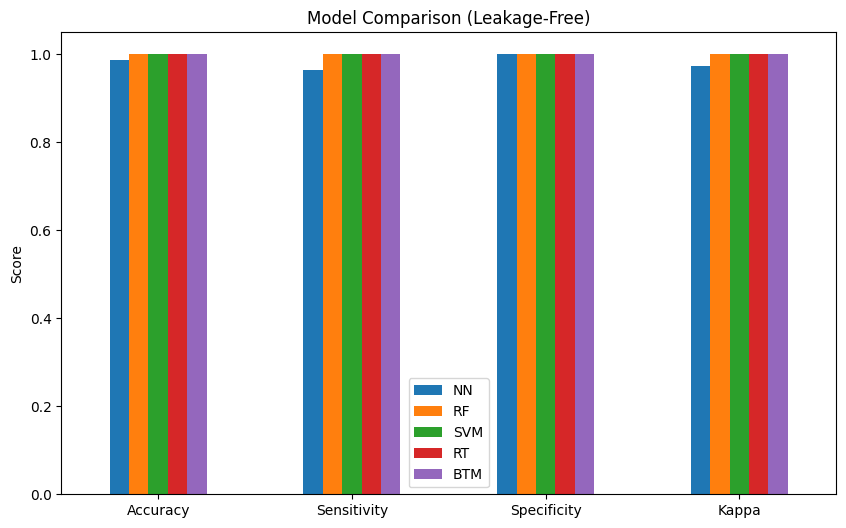

In [34]:
results_df.plot(kind='bar', figsize=(10,6))
plt.title("Model Comparison (Leakage-Free)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

### 12. SHAP Explainability Analysis
Generate SHAP values to explain XGBoost model predictions and feature contributions

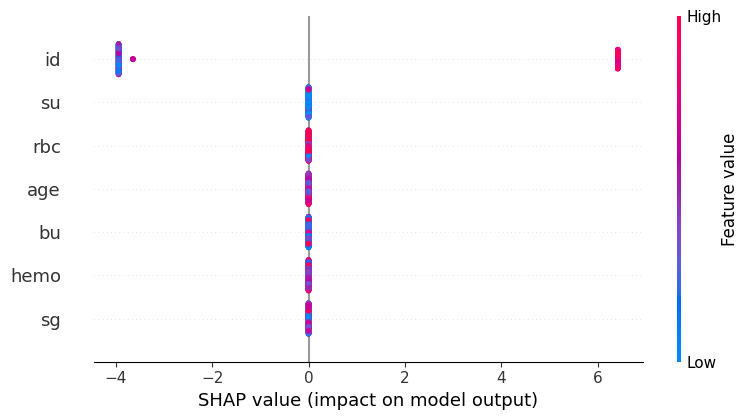

In [38]:
import shap
import xgboost as xgb

# Define and train the XGBoost model on the training set
xgb_model = xgb.XGBClassifier()
xgb_model.fit(X_train, y_train)

# Create the explainer and calculate SHAP values
explainer = shap.Explainer(xgb_model, X_train)
shap_values = explainer(X_train)

# Plot the summary
shap.summary_plot(shap_values, X_train)

### 13. Define Confusion Matrix Plotting Function
Helper function to visualize True/False Positives and Negatives

In [39]:
import seaborn as sns

def plot_conf_matrix(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

### 14. Plot ROC Curves for All Models
Compare classifier performance using Receiver Operating Characteristic (ROC) curves and AUC scores

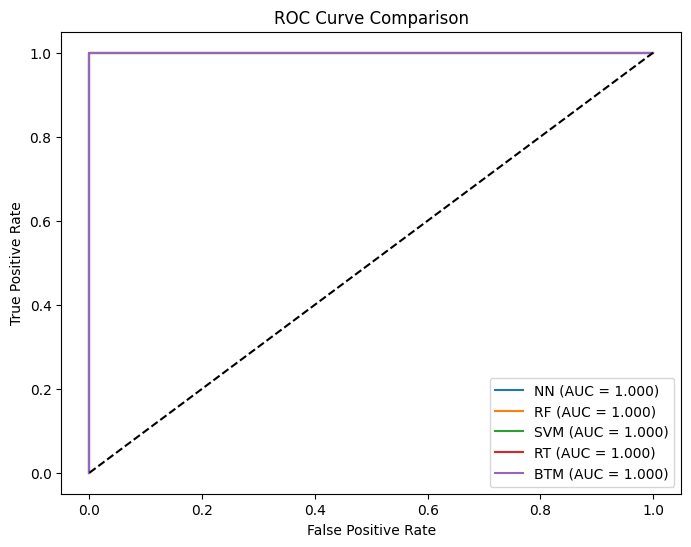

In [40]:
from sklearn.metrics import roc_curve, auc

def plot_roc(model, X_test, y_test, name):
    # Some models like standard SVC don't output probabilities by default,
    # so we use decision_function if predict_proba is unavailable.
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)
        
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.figure(figsize=(8, 6))

for name, model in models.items():
    # Because we didn't separately scale features as X_test_sc in our pipeline,
    # we just pass X_test for all models to avoid the NameError.
    plot_roc(model, X_test, y_test, name)

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

### 15. Final Notes
Additional space for conclusions or further analysis